### Importing modules

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

---

### Loading CSVs into SQLite

In [38]:
conn = sqlite3.connect('olist.db')

files = {
    'orders':   'olist_orders_dataset.csv',
    'items':    'olist_order_items_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'customers':'olist_customers_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'reviews':  'olist_order_reviews_dataset.csv'
}

In [39]:
for table_name, file_name in files.items():
    df = pd.read_csv(file_name)
    df.to_sql(table_name, conn, if_exists = 'replace', index = False)
    print(f"Loaded {table_name}: {len(df):,} rows")

conn.close()
print("Database created: olist.db")

Loaded orders: 99,441 rows
Loaded items: 112,650 rows
Loaded payments: 103,886 rows
Loaded customers: 99,441 rows
Loaded products: 14,529 rows
Loaded reviews: 99,224 rows
Database created: olist.db


---

### Helper funtion to read SQL queries

In [40]:
conn = sqlite3.connect('olist.db')

def query(sql):
    return pd.read_sql_query(sql, conn)

___

### Queries

#### Monthly Revenue Trend

In [44]:
month_revenue_trend = " SELECT strftime('%Y-%m', o.order_purchase_timestamp) AS month, \
ROUND(SUM(p.payment_value),2) AS total_revenue, \
COUNT(DISTINCT o.order_id) AS order_count \
FROM orders o JOIN payments p ON o.order_id = p.order_id \
WHERE o.order_status = 'delivered' AND o.order_purchase_timestamp < '2018-09-01' \
GROUP BY month ORDER BY month;"

query(month_revenue_trend)

,month,total_revenue,order_count
0,2016-10,46566.71,265
1,2016-12,19.62,1
2,2017-01,127545.67,750
3,2017-02,271298.65,1653
4,2017-03,414369.39,2546
5,2017-04,390952.18,2303
6,2017-05,567066.73,3546
7,2017-06,490225.60,3135
8,2017-07,566403.93,3872
9,2017-08,646000.61,4193


#### Top 10 product categories by revenue

In [49]:
top_10_prod = "SELECT p.product_category_name, \
COUNT(DISTINCT i.order_id) AS orders, \
ROUND(SUM(i.price), 2) AS total_revenue, \
ROUND(AVG(i.price), 2) AS avg_price \
FROM items i JOIN products p ON i.product_id = p.product_id \
WHERE p.product_category_name IS NOT NULL \
GROUP BY p.product_category_name ORDER BY total_revenue DESC \
LIMIT 10;"

query(top_10_prod)

,product_category_name,orders,total_revenue,avg_price
0,relogios_presentes,2480,526941.18,204.88
1,beleza_saude,4398,492297.88,103.55
2,cama_mesa_banho,4476,451220.62,89.32
3,esporte_lazer,3280,413966.63,113.88
4,informatica_acessorios,2963,369089.05,109.39
5,moveis_decoracao,3092,344698.83,90.38
6,cool_stuff,1614,300926.38,179.44
7,utilidades_domesticas,2755,296235.92,93.07
8,automotivo,1770,250993.86,132.87
9,ferramentas_jardim,1585,209102.25,104.76


#### Average order value by payment method

In [50]:
avg_ord_val = "SELECT payment_type, \
COUNT(DISTINCT order_id)         AS num_orders, \
ROUND(AVG(payment_value), 2) AS avg_order_value, \
ROUND(SUM(payment_value), 2) AS total_revenue \
FROM payments GROUP BY payment_type ORDER BY total_revenue DESC;"

query(avg_ord_val)

,payment_type,num_orders,avg_order_value,total_revenue
0,credit_card,76505,163.32,12542084.19
1,boleto,19784,145.03,2869361.27
2,voucher,3866,65.70,379436.87
3,debit_card,1528,142.57,217989.79
4,not_defined,3,0.00,0.00


#### Average delivery delay by state

In [56]:
avg_del_date = "SELECT c.customer_state, \
COUNT(*) AS deliveries, \
ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)), 2) \
AS avg_delay_days \
FROM orders o JOIN customers c ON o.customer_id = c.customer_id \
WHERE o.order_delivered_customer_date IS NOT NULL AND o.order_status = 'delivered' \
GROUP BY c.customer_state ORDER BY avg_delay_days DESC \
LIMIT 10;"

query(avg_del_date)

,customer_state,deliveries,avg_delay_days
0,AL,397,-8.03
1,MA,717,-8.89
2,SE,335,-9.33
3,ES,1995,-9.80
4,BA,3256,-10.10
5,CE,1279,-10.11
6,MS,701,-10.36
7,SP,40494,-10.38
8,PI,476,-10.63
9,SC,3546,-10.80


#### Review score distribution

In [60]:
rev_scor_dis = "SELECT review_score,COUNT(*) AS count, \
ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) AS pct \
FROM reviews GROUP BY review_score ORDER BY review_score;"

query(rev_scor_dis)

,review_score,count,pct
0,1,11424,11.5
1,2,3151,3.2
2,3,8179,8.2
3,4,19142,19.3
4,5,57328,57.8


#### Revenue vs average review score by category

In [73]:
rev_vs_avg = "SELECT p.product_category_name, \
ROUND(SUM(i.price), 2) AS total_revenue, \
ROUND(AVG(r.review_score), 2) AS avg_review \
FROM items i \
JOIN products p  ON i.product_id  = p.product_id \
JOIN orders o    ON i.order_id    = o.order_id \
JOIN reviews r   ON o.order_id    = r.order_id \
WHERE p.product_category_name IS NOT NULL \
GROUP BY p.product_category_name HAVING COUNT(*) > 100 \
ORDER BY total_revenue DESC LIMIT 15;"

query(rev_vs_avg)

,product_category_name,total_revenue,avg_review
0,relogios_presentes,523340.13,4.01
1,beleza_saude,488739.69,4.12
2,cama_mesa_banho,453772.84,3.93
3,esporte_lazer,412558.69,4.10
4,informatica_acessorios,369742.39,3.95
5,moveis_decoracao,344285.69,3.93
6,cool_stuff,299683.66,4.17
7,utilidades_domesticas,294614.51,4.06
8,automotivo,248065.32,4.09
9,ferramentas_jardim,208506.93,4.00


#### Repeat customer rate

In [63]:
rep_cus_rate = "WITH customer_orders AS (\
SELECT c.customer_unique_id, \
COUNT(DISTINCT o.order_id) AS total_orders \
FROM orders o JOIN customers c ON o.customer_id = c.customer_id \
GROUP BY c.customer_unique_id) \
SELECT COUNT(*) AS total_customers, \
SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers, \
ROUND(100.0 * SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END)\
/ COUNT(*), 1) AS repeat_rate_pct \
FROM customer_orders;"

query(rep_cus_rate)

,total_customers,repeat_customers,repeat_rate_pct
0,96096,2997,3.1


---

### Charts

#### Monthly Revenue

In [65]:
month_revenue = " SELECT strftime('%Y-%m', o.order_purchase_timestamp) AS month, \
ROUND(SUM(p.payment_value),2) AS total_revenue \
FROM orders o JOIN payments p ON o.order_id = p.order_id \
WHERE o.order_status = 'delivered' AND o.order_purchase_timestamp < '2018-09-01' \
GROUP BY month ORDER BY month;"

df = query(month_revenue)

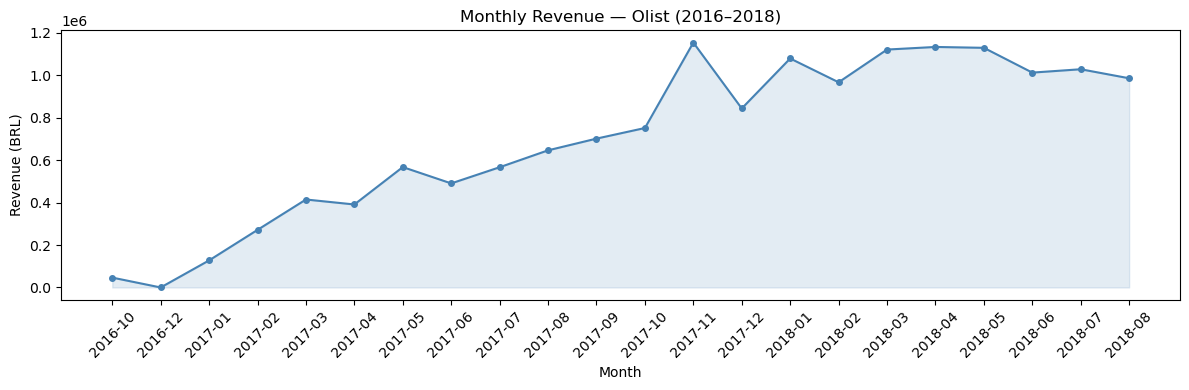

In [67]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['month'], df['total_revenue'], color='steelblue', marker='o', ms=4)
ax.fill_between(df['month'], df['total_revenue'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Revenue — Olist (2016–2018)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('01_monthly_revenue.png', dpi=150)
plt.show()

#### Top Categories

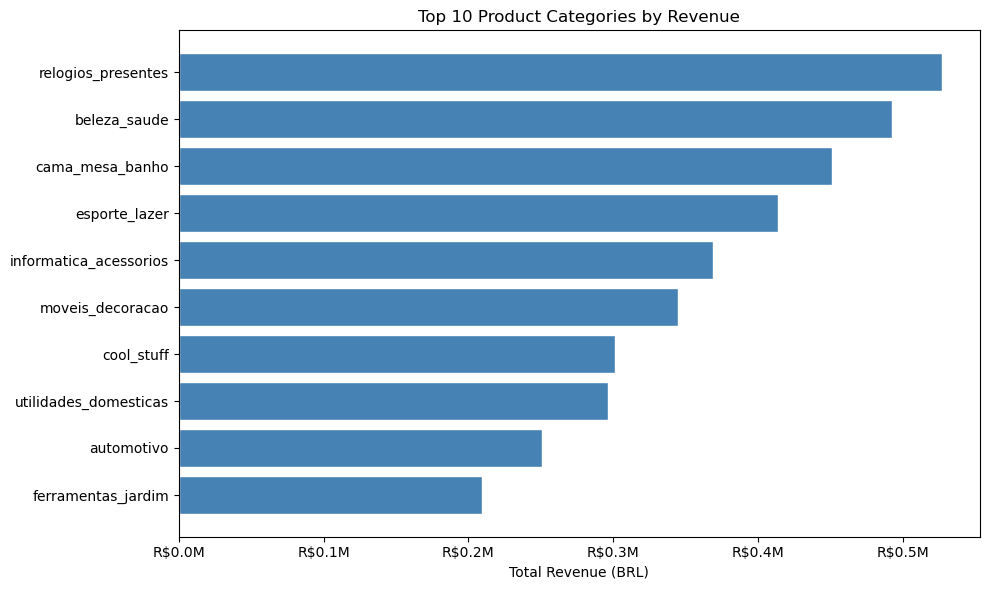

In [68]:
df = query(top_10_prod)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df['product_category_name'], df['total_revenue'],
       color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 10 Product Categories by Revenue')
ax.set_xlabel('Total Revenue (BRL)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('02_top_categories.png', dpi=150)
plt.show()

#### Review Score Distribution

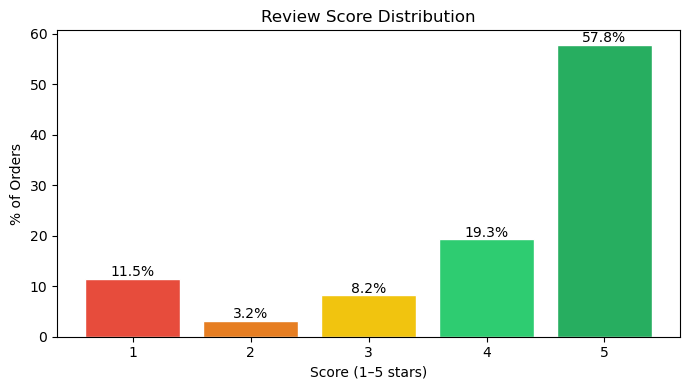

In [69]:
df = query(rev_scor_dis)

colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df['review_score'], df['pct'], color=colors, edgecolor='white')
for bar, pct in zip(bars, df['pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
           bar.get_height() + 0.5,
           f'{pct:.1f}%', ha='center', fontsize=10)
ax.set_title('Review Score Distribution')
ax.set_xlabel('Score (1–5 stars)')
ax.set_ylabel('% of Orders')
plt.tight_layout()
plt.savefig('03_review_scores.png', dpi=150)
plt.show()

#### Revenue vs Review Score

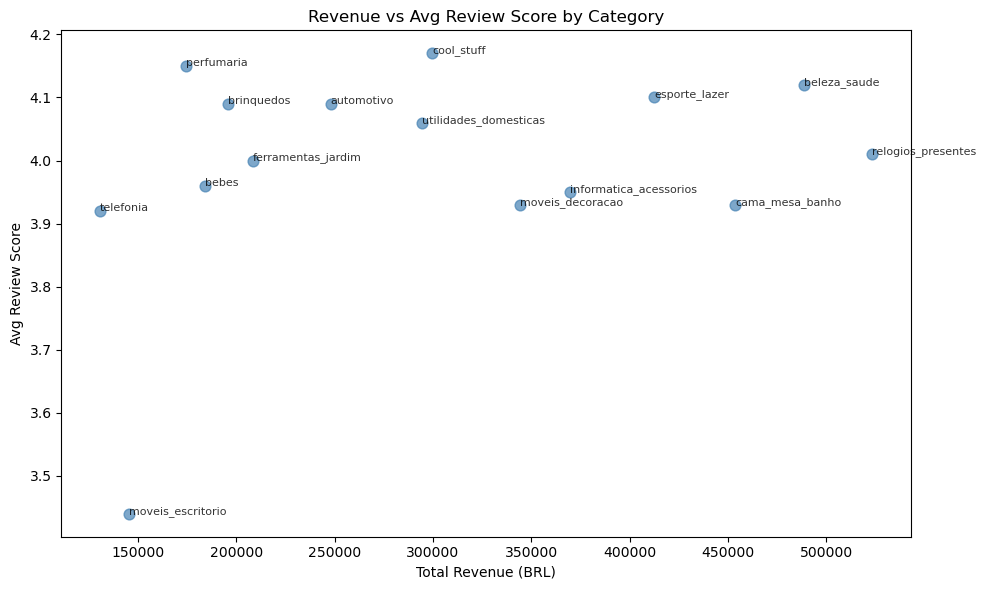

In [74]:
df = query(rev_vs_avg)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['total_revenue'], df['avg_review'],
                     alpha=0.7, color='steelblue', s=60)
for _, row in df.iterrows():
    ax.annotate(row['product_category_name'],
                (row['total_revenue'], row['avg_review']),
                fontsize=8, alpha=0.8)
ax.set_title('Revenue vs Avg Review Score by Category')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Avg Review Score')
plt.tight_layout()
plt.savefig('04_revenue_vs_review.png', dpi=150)
plt.show()

In [75]:
conn.close()

---